# Load Environment

In [1]:
import os
import gzip
import pickle
import numpy as np
import pandas as pd


# ====== score vector column names (matches get_metrics return order) ======
SCORE_COLS = ["aupr", "auc", "f1", "accuracy", "recall", "specificity", "precision"]

# ====== hyperparam columns per method ======
HYPERPARAM_COLS = {
    "bissgl": [
        "xi",
        "eta",
        "tilde_lambda0",
        "tilde_lambda1",
        "lambda0",
        "lambda1",
        "K",
    ],
    "sgimc": ["C_lasso", "C_group", "C_ridge", "rank"],
    "imc": ["C_lasso", "C_group", "C_ridge", "lamb", "rank"],
    "drimc": ["lamU", "lamV", "cc", "iterpara", "numLat"],
    "nrlmf": [
        "c",
        "K1",
        "K2",
        "r",
        "lambda_d",
        "lambda_t",
        "alpha",
        "beta",
        "theta",
        "max_iter",
    ],
}


# ====== load results — single stacked file or multiple task files ======
def load_results(output_dir, method_name):
    """
    Load results for a given method. Handles two cases:
      1. Single stacked file:  results_<method>.gz
      2. Multiple task files:  results_<method>_task*.gz

    Parameters
    ----------
    output_dir  : str  path to the directory containing result files
    method_name : str  one of 'bissgl', 'sgimc', 'imc'

    Returns
    -------
    pd.DataFrame  one row per (dataset, train_size, hyperparam combo, cv fold)
    """
    # prefer single stacked file if it exists
    single_file = os.path.join(output_dir, f"results_{method_name}.gz")
    if os.path.exists(single_file):
        with gzip.open(single_file, "rb") as fin:
            rows = pickle.load(fin)
    else:
        # fall back to multiple task files
        prefix = f"results_{method_name}_task"
        files = sorted(
            f
            for f in os.listdir(output_dir)
            if f.startswith(prefix) and f.endswith(".gz")
        )
        if not files:
            raise FileNotFoundError(
                f"No file 'results_{method_name}.gz' and no task files "
                f"matching '{prefix}*.gz' found in {output_dir}"
            )
        rows = []
        for fname in files:
            with gzip.open(os.path.join(output_dir, fname), "rb") as fin:
                rows.extend(pickle.load(fin))

    df = pd.DataFrame(rows)
    df["val_score"] = df["val_score"].apply(np.asarray)
    df["test_score"] = df["test_score"].apply(np.asarray)
    return df


# ====== expand score vector into named columns ======
def expand_scores(df, col, names=SCORE_COLS):
    """
    Expand a column of score vectors into individual named columns.
    Returns a new DataFrame with columns: <col>_aupr, <col>_auc, etc.
    """
    expanded = pd.DataFrame(
        np.stack(df[col].values), index=df.index, columns=[f"{col}_{n}" for n in names]
    )
    return expanded


# ====== main summarization pipeline ======
def summarize_results(
    df,
    hyperparam_cols,
    val_metric="aupr",
):
    """
    Summarize simulation results with CV-based hyperparameter selection.

    Pipeline
    --------
    1. Average val_score across CV folds per (feature_id, repeat_id, train_size, hyperparams)
    2. Select best hyperparam combo per (feature_id, repeat_id, train_size) by val_metric
    3. Retrieve test_score for the best combo (identical across CV folds — take first row)
    4. Average and std of test_score across repeat_ids per (feature_id, n_features, train_size)

    Parameters
    ----------
    df             : pd.DataFrame  raw results from load_results()
    hyperparam_cols: list[str]     hyperparam column names for this method
    val_metric     : str           which score metric to use for selection (default: 'aupr')

    Returns
    -------
    dict with keys:
        'val_avg'      : val scores averaged over CV folds, per (feature, repeat, train, hyperparams)
        'best_params'  : best hyperparam combo per (feature, repeat, train)
        'test_per_rep' : test scores for best combo per (feature, repeat, train)
        'final'        : mean and std of test scores across repeats per (feature, train)
    """

    id_cols = ["feature_id", "n_features", "repeat_id"]
    cond_cols = ["train_size"]
    # sel_cols = all columns that identify a unique (dataset, condition) pair
    sel_cols = id_cols + cond_cols
    group_cols = sel_cols + hyperparam_cols

    # ------------------------------------------------------------------
    # Step 1: average val_score across CV folds
    # ------------------------------------------------------------------
    val_avg = df.groupby(group_cols, as_index=False).agg(
        val_score=("val_score", lambda x: np.mean(np.stack(x), axis=0)),
        # val_d1=("val_d1", "mean"),
        # val_d2=("val_d2", "mean"),
    )

    # expand val_score vector into named columns for readability
    val_avg = pd.concat(
        [val_avg.drop(columns=["val_score"]), expand_scores(val_avg, "val_score")],
        axis=1,
    )
    val_metric_col = f"val_score_{val_metric}"

    # ------------------------------------------------------------------
    # Step 2: select best hyperparam combo per (feature_id, repeat_id, train_size)
    # ------------------------------------------------------------------
    sel_cols = id_cols + cond_cols
    best_idx = val_avg.groupby(sel_cols)[val_metric_col].idxmax()
    best_params = val_avg.loc[
        best_idx, sel_cols + hyperparam_cols + [val_metric_col]
    ].reset_index(drop=True)

    # ------------------------------------------------------------------
    # Step 3: retrieve test_score for the best combo
    # test_score is identical across CV folds for the same combo,
    # so merge and take the first row per group
    # ------------------------------------------------------------------
    df_best = df.merge(
        best_params[sel_cols + hyperparam_cols],
        on=sel_cols + hyperparam_cols,
        how="inner",
    )

    # deduplicate: one row per (feature_id, repeat_id, train_size)
    test_per_rep = df_best.groupby(sel_cols, as_index=False).first()[
        # sel_cols + hyperparam_cols + ["test_score", "test_d1", "test_d2"]
        sel_cols
        + hyperparam_cols
        + ["test_score"]
    ]

    # expand test_score vector into named columns
    test_per_rep = pd.concat(
        [
            test_per_rep.drop(columns=["test_score"]),
            expand_scores(test_per_rep, "test_score"),
        ],
        axis=1,
    )

    # ------------------------------------------------------------------
    # Step 4: average and std across repeat_ids per (feature_id, train_size)
    # ------------------------------------------------------------------
    test_score_cols = [f"test_score_{n}" for n in SCORE_COLS]

    final = test_per_rep.groupby(
        ["feature_id", "n_features", "train_size"], as_index=False
    ).agg(
        **{f"{c}_mean": (c, "mean") for c in test_score_cols},
        **{f"{c}_std": (c, lambda x: x.std(ddof=1)) for c in test_score_cols},
        # test_d1_mean=("test_d1", "mean"),
        # test_d2_mean=("test_d2", "mean"),
        n_repeats=("repeat_id", "count"),
    )

    return {
        "val_avg": val_avg,
        "best_params": best_params,
        "test_per_rep": test_per_rep,
        "final": final,
    }


# ====== convenience wrapper per method ======
def summarize_method(output_dir, method_name, val_metric="aupr", filters=None):
    """
    Load results and summarize for a given method in one call.

    Parameters
    ----------
    output_dir  : str   path to result files
    method_name : str   one of 'bissgl', 'sgimc', 'imc'
    val_metric  : str   score metric for hyperparam selection (default: 'aupr')
    filters     : dict  optional column filters applied before summarization,
                        e.g. {"xi": 1} to restrict to xi=1 rows only

    Example
    -------
    results = summarize_method(
        output_dir  = "/work/sfan/projects/BiSSGL/outputs/simulations/n_features",
        method_name = "bissgl",
        val_metric  = "aupr",
        filters     = {"xi": 1},
    )
    print(results["final"])
    """
    hyperparam_cols = HYPERPARAM_COLS[method_name]
    df = load_results(output_dir, method_name)

    if filters is not None:
        for col, val in filters.items():
            df = df[df[col] == val]
        df = df.reset_index(drop=True)

    return summarize_results(df, hyperparam_cols, val_metric=val_metric)

In [3]:
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset/cv_data")
PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/cdataset/fold_cv/origin")

# BVSIMC

In [9]:
results_drimc = load_results(
    output_dir=PATH_OUTPUT,
    method_name="drimc",
)

In [6]:
display(results_drimc)

,trial,fold,lamU,lamV,cc,iterpara,numLat,cv,val_score,val_d1,val_d2,test_score,test_d1,test_d2
0,0,0,2,2,1,0.125,200,0,"[0.19078898930035929, 0.8272882814901168, 0.07...",658,409,"[0.2306923906001095, 0.8329980809036668, 0.008...",658,409
1,0,0,2,2,1,0.125,200,1,"[0.16814385860548464, 0.819053032509325, 0.066...",658,409,"[0.2306923906001095, 0.8329980809036668, 0.008...",658,409
2,0,0,2,2,1,0.125,200,2,"[0.18780063356947974, 0.8199941248171865, 0.07...",658,409,"[0.2306923906001095, 0.8329980809036668, 0.008...",658,409
3,0,0,2,2,5,0.125,200,0,"[0.2722923885604528, 0.8563888136278159, 0.333...",658,409,"[0.20107224833776852, 0.8659050117272487, 0.22...",658,409
4,0,0,2,2,5,0.125,200,1,"[0.23238547184964584, 0.8498790130102817, 0.30...",658,409,"[0.20107224833776852, 0.8659050117272487, 0.22...",658,409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,4,9,2,2,5,0.125,200,1,"[0.20514022801705395, 0.8425676151080629, 0.26...",658,409,"[0.19158215001329632, 0.873988847057316, 0.254...",658,409
446,4,9,2,2,5,0.125,200,2,"[0.21388976321707043, 0.8483187713435096, 0.29...",658,409,"[0.19158215001329632, 0.873988847057316, 0.254...",658,409
447,4,9,2,2,10,0.125,200,0,"[0.24204910582442607, 0.8556583030802132, 0.34...",658,409,"[0.18662801816999974, 0.8833790110768529, 0.24...",658,409
448,4,9,2,2,10,0.125,200,1,"[0.21903482205626676, 0.8516270909545656, 0.31...",658,409,"[0.18662801816999974, 0.8833790110768529, 0.24...",658,409


# Plot the trend

In [10]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150  # sharper display in notebook

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# ====== journal-ready style constants ======
# keyed by INTERNAL method name (not display label) to avoid lookup failures
METHOD_STYLE = {
    "bissgl": dict(color="#C0392B", linestyle="-", marker="s"),  # red solid
    "bissgl_xi1": dict(color="#C0392B", linestyle="--", marker="s"),  # red dashed
    "imc": dict(color="#2980B9", linestyle="-", marker="o"),  # blue solid
    "sgimc": dict(color="#2980B9", linestyle="--", marker="o"),  # blue dashed
    "drimc": dict(color="#27AE60", linestyle="-", marker="^"),  # green solid
    "nrlmf": dict(color="#8E44AD", linestyle="-", marker="D"),  # purple solid
}

# map internal method names → base display labels
# annotation (e.g. xi=1) is appended by get_method_label via method_filters
METHOD_LABEL = {
    "bissgl": "BVSIMC",
    "bissgl_xi1": "BVSIMC",  # same base; xi annotation comes from method_filters
    "imc": "IMC",
    "sgimc": "SGIMC",
    "drimc": "DRIMC",
    "nrlmf": "NRLMF",
}


def get_method_label(method_name, filters=None):
    """
    Build a display label for a method, appending filtered hyperparams in LaTeX.
    e.g. get_method_label("bissgl", {"xi": 1}) -> "BVSIMC ($\\xi=1$)"
    """
    base = METHOD_LABEL.get(method_name, method_name)
    if not filters:
        return base

    # LaTeX-friendly param names
    LATEX_PARAM = {
        "xi": r"\xi",
        "tilde_lambda0": r"\tilde{\lambda}_0",
        "lambda0": r"\lambda_0",
        "K": "K",
    }
    parts = []
    for k, v in filters.items():
        latex_k = LATEX_PARAM.get(k, k)
        parts.append(f"${latex_k}={v}$")
    return f"{base} ({', '.join(parts)})"


SCORE_COLS = ["aupr", "auc", "f1", "accuracy", "recall", "specificity", "precision"]
SCORE_LABEL = {
    "aupr": "AUPR",
    "auc": "AUC",
    "f1": "F1 Score",
    "accuracy": "Accuracy",
    "recall": "Recall",
    "specificity": "Specificity",
    "precision": "Precision",
}

# shared rcParams for journal style
RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
}


def _plot_one_method(ax, final_df, x_col, metric, label, style):
    """
    Plot a single method curve with error band on a given axes.

    Parameters
    ----------
    ax       : matplotlib Axes
    final_df : pd.DataFrame  output of summarize_method()["final"]
    x_col    : str           column to use as x-axis ('train_size' or 'n_features')
    metric   : str           one of SCORE_COLS
    label    : str           display label for legend
    style    : dict          line/marker style from METHOD_STYLE
    """
    mean_col = f"test_score_{metric}_mean"
    std_col = f"test_score_{metric}_std"

    sub = final_df.sort_values(x_col)
    x = sub[x_col].values
    y = sub[mean_col].values
    ye = sub[std_col].values

    ax.plot(
        x,
        y,
        label=label,
        linewidth=2.0,
        markersize=7,
        markerfacecolor="white",
        markeredgewidth=1.8,
        **style,
    )
    ax.fill_between(
        x,
        y - ye,
        y + ye,
        color=style["color"],
        alpha=0.12,
        linewidth=0,
    )


def plot_vs_train_size(
    results_dict,
    metric="aupr",
    n_features=None,
    method_filters=None,
    ylim=None,
    figsize=(6, 4.5),
    savepath=None,
):
    """
    Plot metric vs training size for each method, optionally filtered to one feature size.

    Parameters
    ----------
    results_dict   : dict  {method_name: final_df}
    metric         : str   score metric to plot (default: 'aupr')
    n_features     : int   if given, restrict to this feature size; otherwise average over all
    method_filters : dict  {method_name: filter_dict} used to build display labels,
                           e.g. {"bissgl": {"xi": 1}}
    ylim           : tuple optional (ymin, ymax)
    figsize        : tuple figure size in inches
    savepath       : str   optional save path (e.g. 'fig.pdf')

    Example
    -------
    plot_vs_train_size(
        {"bissgl": results_b["final"], "imc": results_i["final"]},
        metric="aupr",
        n_features=300,
        method_filters={"bissgl": {"xi": 1}},
    )
    """
    method_filters = method_filters or {}

    with plt.rc_context(RC):
        fig, ax = plt.subplots(figsize=figsize)

        for method_name, final_df in results_dict.items():
            filters = method_filters.get(method_name)
            label = get_method_label(method_name, filters)
            style = METHOD_STYLE.get(
                method_name, dict(color="gray", linestyle="-", marker="o")
            )

            df = final_df.copy()
            if n_features is not None:
                df = df[df["n_features"] == n_features]
            else:
                mean_col = f"test_score_{metric}_mean"
                std_col = f"test_score_{metric}_std"
                df = df.groupby("train_size", as_index=False).agg(
                    {mean_col: "mean", std_col: "mean"}
                )

            _plot_one_method(ax, df, "train_size", metric, label, style)

        ax.set_xlabel("Training Size", fontsize=13, labelpad=8)
        ax.set_ylabel(SCORE_LABEL.get(metric, metric), fontsize=13, labelpad=8)

        title_suffix = (
            f" (Number of Features = {n_features})" if n_features is not None else ""
        )
        ax.set_title(
            f"{SCORE_LABEL.get(metric, metric)} vs Training Size{title_suffix}",
            fontsize=13,
            pad=10,
        )

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=0))
        ax.tick_params(labelsize=11)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
        ax.legend(fontsize=11, loc="lower right", frameon=False, handlelength=3.0)

        fig.tight_layout()
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()


def plot_vs_n_features(
    results_dict,
    metric="aupr",
    train_size=0.1,
    method_filters=None,
    ylim=None,
    figsize=(6, 4.5),
    savepath=None,
):
    """
    Plot metric vs number of features for each method at a fixed training size.

    Parameters
    ----------
    results_dict   : dict  {method_name: final_df}
    metric         : str   score metric to plot (default: 'aupr')
    train_size     : float fixed training size level to slice (default: 0.1)
    method_filters : dict  {method_name: filter_dict} for display labels
    ylim           : tuple optional (ymin, ymax)
    figsize        : tuple figure size in inches
    savepath       : str   optional save path

    Example
    -------
    plot_vs_n_features(
        {"bissgl": results_b["final"], "imc": results_i["final"]},
        metric="aupr",
        train_size=0.1,
        method_filters={"bissgl": {"xi": 1}},
    )
    """
    method_filters = method_filters or {}

    with plt.rc_context(RC):
        fig, ax = plt.subplots(figsize=figsize)

        for method_name, final_df in results_dict.items():
            filters = method_filters.get(method_name)
            label = get_method_label(method_name, filters)
            style = METHOD_STYLE.get(
                method_name, dict(color="gray", linestyle="-", marker="o")
            )

            available = final_df["train_size"].unique()
            closest = available[np.argmin(np.abs(available - train_size))]
            df = final_df[final_df["train_size"] == closest].copy()

            _plot_one_method(ax, df, "n_features", metric, label, style)

        ax.set_xlabel("Number of Features", fontsize=13, labelpad=8)
        ax.set_ylabel(SCORE_LABEL.get(metric, metric), fontsize=13, labelpad=8)
        ax.set_title(
            f"{SCORE_LABEL.get(metric, metric)} vs Number of Features"
            f" (Training Size = {train_size:.0%})",
            fontsize=13,
            pad=10,
        )

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.tick_params(labelsize=11)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
        ax.legend(fontsize=11, loc="lower right", frameon=False, handlelength=3.0)

        fig.tight_layout()
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()


def plot_both(
    results_dict,
    metric="aupr",
    n_features_for_train_plot=None,
    train_size_for_feature_plot=0.1,
    method_filters=None,
    ylim=None,
    figsize=(14, 5),
    savepath=None,
):
    """
    Side-by-side figure: left panel = metric vs training size,
    right panel = metric vs number of features.

    Parameters
    ----------
    results_dict                : dict  {method_name: final_df}
    metric                      : str   score metric (default: 'aupr')
    n_features_for_train_plot   : int   optional feature size filter for left panel
    train_size_for_feature_plot : float fixed training size for right panel (default: 0.1)
    method_filters              : dict  {method_name: filter_dict} for display labels
    ylim                        : tuple y-axis limits, default (0.5, 1.01)
    figsize                     : tuple figure size in inches, default (14, 5)
    savepath                    : str   optional save path

    Example
    -------
    plot_both(
        {"bissgl": results_b["final"], "imc": results_i["final"]},
        metric="aupr",
        train_size_for_feature_plot=0.1,
        method_filters={"bissgl": {"xi": 1}},
    )
    """
    method_filters = method_filters or {}
    if ylim is None:
        ylim = (0.5, 1.01)

    with plt.rc_context(RC):
        fig, axes = plt.subplots(1, 2, figsize=figsize)

        # ---- left panel: vs training size ----
        ax = axes[0]
        for method_name, final_df in results_dict.items():
            filters = method_filters.get(method_name)
            label = get_method_label(method_name, filters)
            style = METHOD_STYLE.get(
                method_name, dict(color="gray", linestyle="-", marker="o")
            )
            df = final_df.copy()
            if n_features_for_train_plot is not None:
                df = df[df["n_features"] == n_features_for_train_plot]
            else:
                mean_col = f"test_score_{metric}_mean"
                std_col = f"test_score_{metric}_std"
                df = df.groupby("train_size", as_index=False).agg(
                    {mean_col: "mean", std_col: "mean"}
                )
            _plot_one_method(ax, df, "train_size", metric, label, style)

        ax.set_xlabel("Training Size", fontsize=13, labelpad=8)
        ax.set_ylabel(SCORE_LABEL.get(metric, metric), fontsize=13, labelpad=8)
        suffix = (
            f" (Number of Features = {n_features_for_train_plot})"
            if n_features_for_train_plot
            else ""
        )
        ax.set_title(
            f"(A)  {SCORE_LABEL.get(metric, metric)} vs Training Size{suffix}",
            fontsize=13,
            pad=10,
        )
        ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=0))
        ax.set_ylim(ylim)
        ax.tick_params(labelsize=11)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
        # increasing trend → legend safe at lower right
        ax.legend(
            fontsize=10,
            loc="lower right",
            frameon=True,
            handlelength=3.0,
            framealpha=0.7,
            edgecolor="none",
        )

        # ---- right panel: vs number of features ----
        ax = axes[1]
        for method_name, final_df in results_dict.items():
            filters = method_filters.get(method_name)
            label = get_method_label(method_name, filters)
            style = METHOD_STYLE.get(
                method_name, dict(color="gray", linestyle="-", marker="o")
            )
            available = final_df["train_size"].unique()
            closest = available[
                np.argmin(np.abs(available - train_size_for_feature_plot))
            ]
            df = final_df[final_df["train_size"] == closest].copy()
            _plot_one_method(ax, df, "n_features", metric, label, style)

        ax.set_xlabel("Number of Features", fontsize=13, labelpad=8)
        ax.set_ylabel(SCORE_LABEL.get(metric, metric), fontsize=13, labelpad=8)
        ax.set_title(
            f"(B)  {SCORE_LABEL.get(metric, metric)} vs Number of Features"
            f" (Training Size = {train_size_for_feature_plot:.0%})",
            fontsize=13,
            pad=10,
        )
        ax.set_ylim(ylim)
        ax.tick_params(labelsize=11)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
        # decreasing trend → legend safe at upper right
        ax.legend(
            fontsize=10,
            loc="lower right",
            frameon=True,
            handlelength=3.0,
            framealpha=0.7,
            edgecolor="none",
        )

        fig.tight_layout()
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

In [15]:
# load summaries
final = {
    "bissgl_xi1": summarize_method(PATH_OUTPUT, "bissgl", filters={"xi": 1})["final"],
    "bissgl": summarize_method(PATH_OUTPUT, "bissgl")["final"],
    "imc": summarize_method(PATH_OUTPUT, "imc")["final"],
    "sgimc": summarize_method(PATH_OUTPUT, "sgimc")["final"],
    "drimc": summarize_method(PATH_OUTPUT, "drimc")["final"],
    "nrlmf": summarize_method(PATH_OUTPUT, "nrlmf")["final"],
}

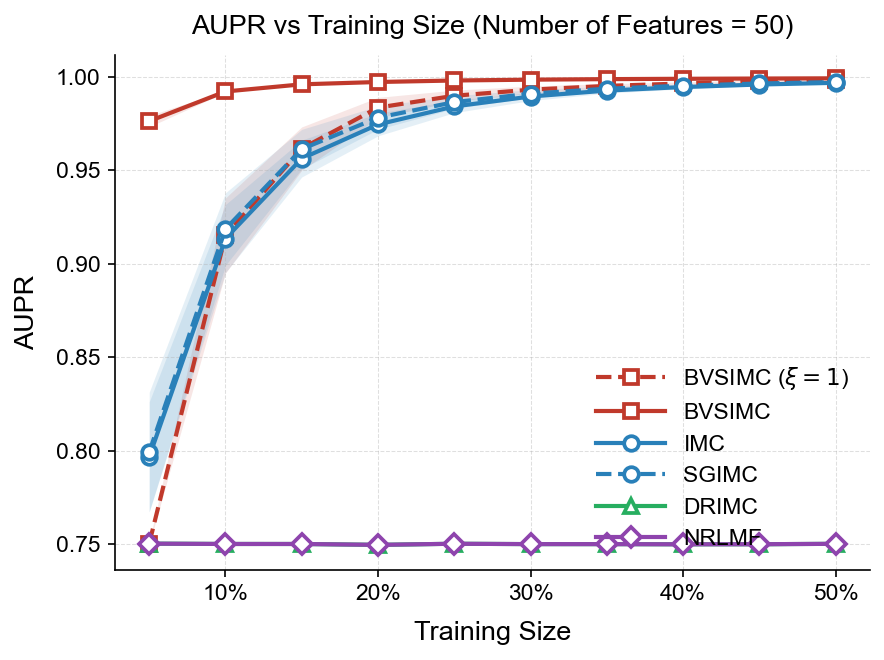

In [16]:
# individual plots
# plot_vs_train_size(final, metric="aupr", n_features=50)
plot_vs_train_size(
    final,
    metric="aupr",
    n_features=50,
    method_filters={"bissgl_xi1": {"xi": 1}},
)

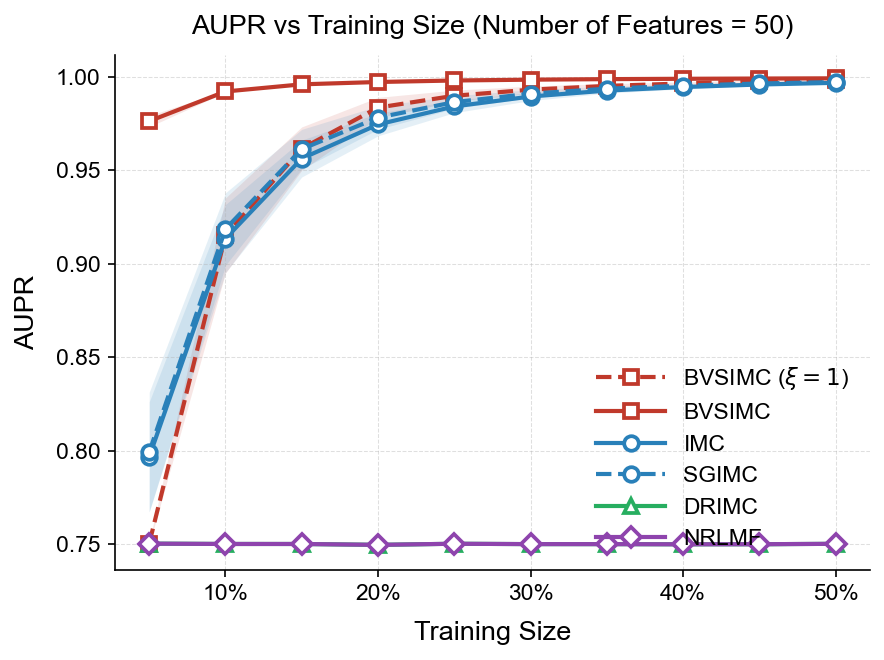

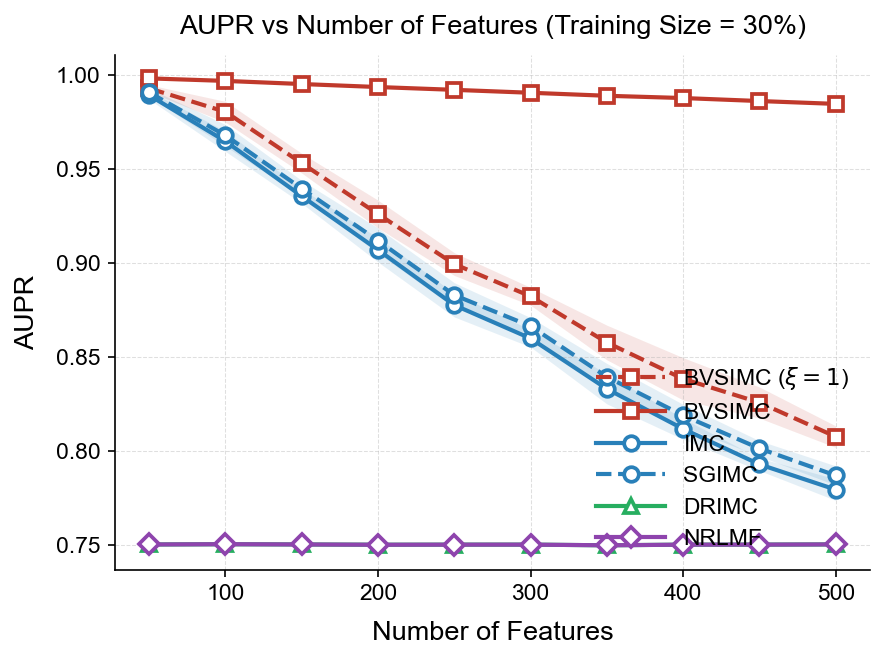

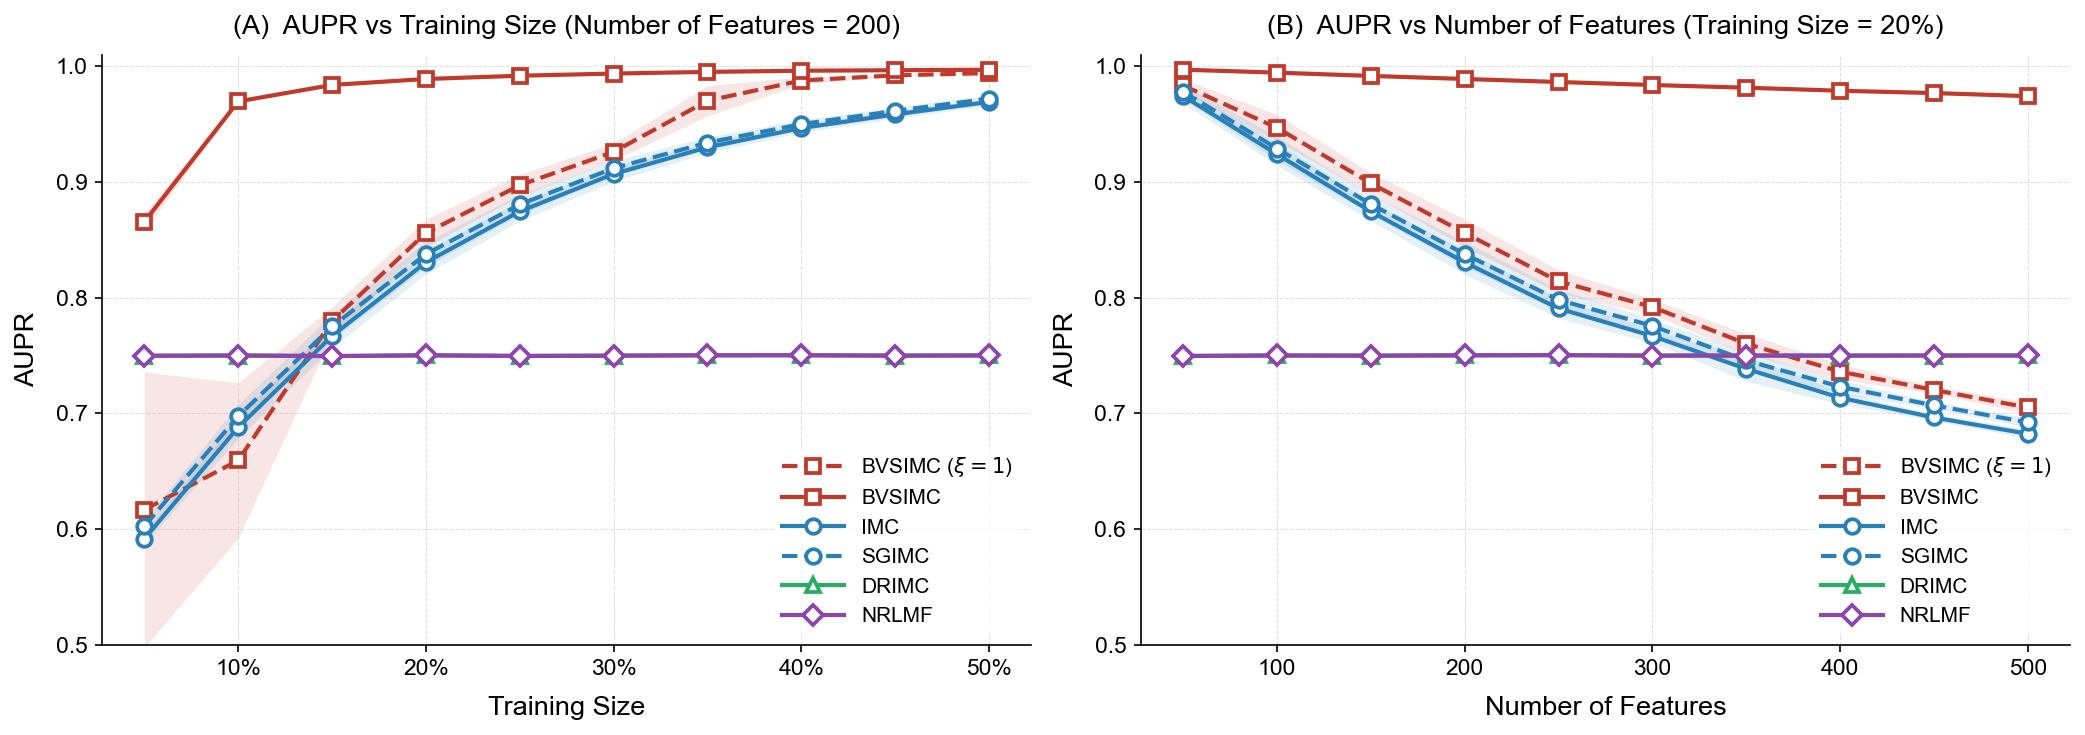

In [23]:
plot_vs_train_size(
    final,
    metric="aupr",
    n_features=50,
    method_filters={"bissgl_xi1": {"xi": 1}},
)

plot_vs_n_features(
    final,
    metric="aupr",
    train_size=0.3,
    method_filters={"bissgl_xi1": {"xi": 1}},
)

plot_both(
    final,
    metric="aupr",
    method_filters={"bissgl_xi1": {"xi": 1}},
    n_features_for_train_plot=200,
    train_size_for_feature_plot=0.2,
)

---

# Summarize the results

In [1]:
"""
Summarize real-application CV results with nested HP selection.

Structure
---------
Raw data: 5 trials × 10 folds × HP combos × 3 inner CV folds

Pipeline (mirrors simulation summarize_results.py)
---------------------------------------------------
Step 1: Average val_score across 3 inner CV folds
        → one row per (trial, fold, HP combo)

Step 2: Select best HP combo per (trial, fold) by val_metric
        → one row per (trial, fold)

Step 3: Retrieve test_score for the best combo per (trial, fold)
        (test_score is identical across inner CV folds for the same combo)
        → one row per (trial, fold)

Step 4: Average test_score across 10 folds per trial
        → one row per trial

Step 5: Mean ± std across 5 trials
        → final summary
"""

import os
import gzip
import pickle
import numpy as np
import pandas as pd


# ====== score vector column names (matches get_metrics return order) ======
SCORE_COLS = ["aupr", "auc", "f1", "accuracy", "recall", "specificity", "precision"]

# ====== hyperparam columns per method ======
HYPERPARAM_COLS = {
    "bissgl": [
        "xi",
        "eta",
        "tilde_lambda0",
        "tilde_lambda1",
        "lambda0",
        "lambda1",
        "K",
    ],
    "sgimc": ["C_lasso", "C_group", "C_ridge", "rank"],
    "imc": ["C_lasso", "C_group", "C_ridge", "lamb", "rank"],
    "drimc": ["lamU", "lamV", "cc", "iterpara", "numLat"],
    "nrlmf": [
        "cfix",
        "K1",
        "K2",
        "num_factors",
        "lambda_d",
        "lambda_t",
        "alpha",
        "beta",
        "theta",
        "max_iter",
    ],
}


# ====== load results — single stacked file or multiple task files ======
def load_results(output_dir, method_name):
    """
    Load results for a given method.

    Handles two layouts:
      1. Single stacked file:  results_<method>.gz       (from local runs)
      2. Multiple task files:  results_<method>_task*.gz  (from HPC runs)

    Returns
    -------
    pd.DataFrame  one row per (trial, fold, HP combo, inner CV fold)
    """
    single_file = os.path.join(output_dir, f"results_{method_name}.gz")
    if os.path.exists(single_file):
        with gzip.open(single_file, "rb") as fin:
            rows = pickle.load(fin)
    else:
        prefix = f"results_{method_name}_task"
        files = sorted(
            f
            for f in os.listdir(output_dir)
            if f.startswith(prefix) and f.endswith(".gz")
        )
        if not files:
            raise FileNotFoundError(
                f"No file 'results_{method_name}.gz' and no task files "
                f"matching '{prefix}*.gz' found in {output_dir}"
            )
        rows = []
        for fname in files:
            with gzip.open(os.path.join(output_dir, fname), "rb") as fin:
                rows.extend(pickle.load(fin))

    df = pd.DataFrame(rows)
    df["val_score"] = df["val_score"].apply(np.asarray)
    df["test_score"] = df["test_score"].apply(np.asarray)
    return df


# ====== expand score vector into named columns ======
def expand_scores(df, col, names=SCORE_COLS):
    """
    Expand a column of score vectors into individual named columns.
    e.g. 'val_score' → 'val_score_aupr', 'val_score_auc', ...
    """
    expanded = pd.DataFrame(
        np.stack(df[col].values),
        index=df.index,
        columns=[f"{col}_{n}" for n in names],
    )
    return expanded


# ====== main summarization pipeline ======
def summarize_results(df, hyperparam_cols, val_metric="aupr"):
    """
    Summarize real-application CV results with nested HP selection.

    Pipeline  (analogous to simulation summarize_results)
    --------
    1. Average val_score across 3 inner CV folds
       → per (trial, fold, HP combo)

    2. Select best HP combo per (trial, fold) by val_metric
       → per (trial, fold)

    3. Retrieve test_score for the best combo
       (test_score is identical across inner CV folds for the same HP combo,
        so we merge on (trial, fold, HPs) and take first row per (trial, fold))

    4. Average test_score across 10 folds per trial
       → per trial

    5. Mean ± std across 5 trials
       → single-row final summary

    Parameters
    ----------
    df             : pd.DataFrame  raw results from load_results()
    hyperparam_cols: list[str]     HP column names for this method
    val_metric     : str           score metric for HP selection (default: 'aupr')

    Returns
    -------
    dict with keys:
        'raw'            : original DataFrame (after any filters)
        'val_avg'        : Step 1 output
        'best_params'    : Step 2 output
        'test_per_fold'  : Step 3 output — test scores for best HP per (trial, fold)
        'test_per_trial' : Step 4 output — averaged across folds per trial
        'final'          : Step 5 output — mean ± std across trials
    """
    fold_cols = ["trial", "fold"]
    group_cols = fold_cols + hyperparam_cols

    # ------------------------------------------------------------------
    # Step 1: average val_score across inner CV folds
    #         group by (trial, fold, HP combo), average over cv=0,1,2
    # ------------------------------------------------------------------
    val_avg = df.groupby(group_cols, as_index=False).agg(
        val_score=("val_score", lambda x: np.mean(np.stack(x), axis=0)),
        val_d1=("val_d1", "mean"),
        val_d2=("val_d2", "mean"),
        n_inner_cv=("cv", "count"),  # diagnostic: should be 3
    )

    # expand val_score vector into named columns
    val_avg = pd.concat(
        [val_avg.drop(columns=["val_score"]), expand_scores(val_avg, "val_score")],
        axis=1,
    )
    val_metric_col = f"val_score_{val_metric}"

    # ------------------------------------------------------------------
    # Step 2: select best HP combo per (trial, fold)
    #         pick the HP combo with highest val_metric per outer fold
    # ------------------------------------------------------------------
    best_idx = val_avg.groupby(fold_cols)[val_metric_col].idxmax()
    best_params = val_avg.loc[
        best_idx, fold_cols + hyperparam_cols + [val_metric_col, "n_inner_cv"]
    ].reset_index(drop=True)

    # ------------------------------------------------------------------
    # Step 3: retrieve test_score for the best combo per (trial, fold)
    #         test_score is the same across inner CV folds for the same
    #         (trial, fold, HP) combo, so merge and deduplicate
    # ------------------------------------------------------------------
    df_best = df.merge(
        best_params[fold_cols + hyperparam_cols],
        on=fold_cols + hyperparam_cols,
        how="inner",
    )

    # detect available columns (feature selection indices may or may not exist)
    base_cols = fold_cols + hyperparam_cols + ["test_score", "test_d1", "test_d2"]
    sel_cols_available = [
        c
        for c in ["test_sel_W", "test_sel_H", "test_sel_A", "test_sel_B"]
        if c in df_best.columns
    ]
    keep_cols = base_cols + sel_cols_available

    # deduplicate: one row per (trial, fold)
    test_per_fold = df_best.groupby(fold_cols, as_index=False).first()[keep_cols]

    # expand test_score vector into named columns
    test_per_fold = pd.concat(
        [
            test_per_fold.drop(columns=["test_score"]),
            expand_scores(test_per_fold, "test_score"),
        ],
        axis=1,
    )

    # ------------------------------------------------------------------
    # Step 4: average test_score across 10 folds per trial
    # ------------------------------------------------------------------
    test_score_cols = [f"test_score_{n}" for n in SCORE_COLS]

    test_per_trial = test_per_fold.groupby("trial", as_index=False).agg(
        **{c: (c, "mean") for c in test_score_cols},
        test_d1_mean=("test_d1", "mean"),
        test_d2_mean=("test_d2", "mean"),
        n_folds=("fold", "count"),
    )

    # ------------------------------------------------------------------
    # Step 5: mean ± std across 5 trials
    # ------------------------------------------------------------------
    final = {}
    for c in test_score_cols:
        vals = test_per_trial[c].values
        final[f"{c}_mean"] = vals.mean()
        final[f"{c}_std"] = vals.std(ddof=1)
    final["test_d1_mean"] = test_per_trial["test_d1_mean"].mean()
    final["test_d2_mean"] = test_per_trial["test_d2_mean"].mean()
    final["n_trials"] = len(test_per_trial)
    final["n_folds_per_trial"] = int(test_per_trial["n_folds"].iloc[0])
    final = pd.DataFrame([final])

    return {
        "raw": df,
        "val_avg": val_avg,
        "best_params": best_params,
        "test_per_fold": test_per_fold,
        "test_per_trial": test_per_trial,
        "final": final,
    }


# ====== convenience wrapper per method ======
def summarize_method(output_dir, method_name, val_metric="aupr", filters=None):
    """
    Load results and summarize for a given method in one call.

    Parameters
    ----------
    output_dir  : str   path to result files
    method_name : str   one of 'bissgl', 'sgimc', 'imc', 'drimc', 'nrlmf'
    val_metric  : str   score metric for HP selection (default: 'aupr')
    filters     : dict  optional column filters, e.g. {"xi": 1}

    Example
    -------
    results = summarize_method(
        "/work/sfan/projects/BiSSGL/outputs/results/realAnalysis/tuberculosis/fold_cv",
        "bissgl", val_metric="aupr", filters={"xi": 1},
    )
    print_summary(results, "BVSIMC (xi=1)")
    """
    hyperparam_cols = HYPERPARAM_COLS[method_name]
    df = load_results(output_dir, method_name)

    if filters is not None:
        for col, val in filters.items():
            df = df[df[col] == val]
        df = df.reset_index(drop=True)

    return summarize_results(df, hyperparam_cols, val_metric=val_metric)


# ====== diagnostics ======
def check_completeness(results, method_name, expected_trials=5, expected_folds=10):
    """
    Print diagnostic info to verify results are complete.

    Checks:
    - Number of raw rows
    - Number of (trial, fold) pairs with results
    - Number of inner CV folds per combo
    - Number of HP combos per fold
    """
    df = results["raw"]
    tpf = results["test_per_fold"]

    n_raw = len(df)
    n_outer_folds = len(tpf)
    expected_outer = expected_trials * expected_folds

    # count unique HP combos
    hyperparam_cols = HYPERPARAM_COLS[method_name]
    hp_combos = df.groupby(hyperparam_cols).ngroups

    # inner CV fold count per combo
    inner_counts = df.groupby(["trial", "fold"] + hyperparam_cols)["cv"].count()

    print(f"\n{'='*60}")
    print(f"  Diagnostics: {method_name}")
    print(f"{'='*60}")
    print(f"  Raw result rows:             {n_raw}")
    print(f"  HP combos:                   {hp_combos}")
    print(f"  Expected inner CV per combo:  3")
    print(f"  Actual inner CV (min/max):    {inner_counts.min()}/{inner_counts.max()}")
    print(f"  Outer folds with results:    {n_outer_folds} / {expected_outer} expected")

    # check for missing (trial, fold) pairs
    all_pairs = set(
        (t, f) for t in range(expected_trials) for f in range(expected_folds)
    )
    present_pairs = set(zip(tpf["trial"], tpf["fold"]))
    missing = all_pairs - present_pairs
    if missing:
        print(f"  *** MISSING folds: {sorted(missing)}")
    else:
        print(f"  All {expected_outer} outer folds present ✓")
    print(f"{'='*60}\n")


# ====== pretty-print single method ======
def print_summary(results, method_label="Method"):
    """Print a compact summary of the final results."""
    final = results["final"]
    n_trials = int(final["n_trials"].iloc[0])
    n_folds = int(final["n_folds_per_trial"].iloc[0])
    print(f"\n{'='*60}")
    print(f"  {method_label}  —  {n_trials} trials × {n_folds}-fold CV")
    print(f"{'='*60}")
    for metric in SCORE_COLS:
        m = final[f"test_score_{metric}_mean"].iloc[0]
        s = final[f"test_score_{metric}_std"].iloc[0]
        print(f"  {metric:>12s}:  {m:.4f} ± {s:.4f}")
    print(f"  {'d1 (mean)':>12s}:  {final['test_d1_mean'].iloc[0]:.1f}")
    print(f"  {'d2 (mean)':>12s}:  {final['test_d2_mean'].iloc[0]:.1f}")
    print(f"{'='*60}\n")


# ====== pretty-print comparison across methods ======
def print_all_summaries(all_results):
    """
    Print a comparison table across all methods.

    Parameters
    ----------
    all_results : dict  {method_label: results_dict}
                  e.g. {"BVSIMC": results_bissgl, "SGIMC": results_sgimc, ...}

    Example
    -------
    all_results = {
        "BVSIMC":  summarize_method(PATH, "bissgl", filters={"xi": 1}),
        "SGIMC":   summarize_method(PATH, "sgimc"),
        "IMC":     summarize_method(PATH, "imc"),
        "DRIMC":   summarize_method(PATH, "drimc"),
        "NRLMF":   summarize_method(PATH, "nrlmf"),
    }
    print_all_summaries(all_results)
    """
    methods = list(all_results.keys())
    col_w = max(16, max(len(m) for m in methods) + 2)

    # header
    print(f"\n{'='*(14 + col_w * len(methods) + 2 * len(methods))}")
    print(f"  {'Metric':<14s}", end="")
    for m in methods:
        print(f"  {m:>{col_w}s}", end="")
    print()
    print(f"{'='*(14 + col_w * len(methods) + 2 * len(methods))}")

    for metric in SCORE_COLS:
        print(f"  {metric:<14s}", end="")
        for m in methods:
            final = all_results[m]["final"]
            mean = final[f"test_score_{metric}_mean"].iloc[0]
            std = final[f"test_score_{metric}_std"].iloc[0]
            print(f"  {mean:.4f}±{std:.4f}", end="")
        print()

    # d1, d2
    for d_metric, d_label in [
        ("test_d1_mean", "d1 (mean)"),
        ("test_d2_mean", "d2 (mean)"),
    ]:
        print(f"  {d_label:<14s}", end="")
        for m in methods:
            val = all_results[m]["final"][d_metric].iloc[0]
            print(f"  {val:>{col_w}.1f}", end="")
        print()

    print(f"{'='*(14 + col_w * len(methods) + 2 * len(methods))}\n")


# ====== feature selection frequency analysis ======
def get_feature_frequency(results, sel_col, feature_names=None):
    """
    Count selection frequency and aggregate importance (L2 norm) across folds.

    The sel_col column should contain dicts of {feature_idx: L2_row_norm}.
    Only works for methods that store feature selection info
    (BiSSGL: test_sel_A / test_sel_B,  SGIMC: test_sel_W / test_sel_H).

    Parameters
    ----------
    results       : dict   output of summarize_method()
    sel_col       : str    column name, e.g. 'test_sel_A' or 'test_sel_W'
    feature_names : list   optional feature names to map indices to

    Returns
    -------
    pd.DataFrame  sorted by frequency (descending), with columns:
        feature_idx   : int     0-based feature index
        feature_name  : str     (if feature_names provided)
        count         : int     number of folds where this feature was selected
        frequency     : float   count / total number of folds
        norm_mean     : float   mean L2 row norm across folds where selected
        norm_std      : float   std of L2 row norm across those folds
    """
    tpf = results["test_per_fold"]

    if sel_col not in tpf.columns:
        available = [c for c in tpf.columns if c.startswith("test_sel_")]
        raise KeyError(
            f"Column '{sel_col}' not found in test_per_fold. "
            f"Available selection columns: {available}"
        )

    n_folds = len(tpf)

    # collect all norms per feature index
    from collections import defaultdict

    norms_by_idx = defaultdict(list)
    for sel_dict in tpf[sel_col]:
        if isinstance(sel_dict, dict):
            for idx, norm in sel_dict.items():
                norms_by_idx[int(idx)].append(float(norm))
        else:
            # backward compatibility: plain list of indices (no norms)
            for idx in sel_dict:
                norms_by_idx[int(idx)].append(np.nan)

    # build output DataFrame
    rows = []
    for feat_idx in sorted(norms_by_idx.keys()):
        norms = norms_by_idx[feat_idx]
        row = {
            "feature_idx": feat_idx,
            "count": len(norms),
            "frequency": len(norms) / n_folds,
            "norm_mean": float(np.nanmean(norms)),
            "norm_std": float(np.nanstd(norms, ddof=1)) if len(norms) > 1 else 0.0,
        }
        if feature_names is not None:
            row["feature_name"] = feature_names[feat_idx]
        rows.append(row)

    freq_df = pd.DataFrame(rows)

    # order columns nicely
    col_order = ["feature_idx"]
    if feature_names is not None:
        col_order.append("feature_name")
    col_order.extend(["count", "frequency", "norm_mean", "norm_std"])
    freq_df = (
        freq_df[col_order].sort_values("count", ascending=False).reset_index(drop=True)
    )

    return freq_df


def print_top_features(freq_df, top_n=20, label="Features"):
    """Print the top-N most frequently selected features with importance."""
    n_total = (
        int(round(freq_df["count"].iloc[0] / freq_df["frequency"].iloc[0]))
        if len(freq_df) > 0
        else 0
    )
    print(f"\n{'='*70}")
    print(f"  Top {top_n} {label}  (out of {n_total} outer folds)")
    print(f"{'='*70}")
    has_name = "feature_name" in freq_df.columns
    has_norm = "norm_mean" in freq_df.columns and not freq_df["norm_mean"].isna().all()
    for _, row in freq_df.head(top_n).iterrows():
        name_str = f"  {row['feature_name']}" if has_name else ""
        norm_str = (
            f"  ||r||={row['norm_mean']:.3f}±{row['norm_std']:.3f}" if has_norm else ""
        )
        print(
            f"  idx {row['feature_idx']:>4d}{name_str:30s}  "
            f"count={row['count']:>3d}  freq={row['frequency']:.0%}{norm_str}"
        )
    print(f"{'='*70}\n")

In [2]:
"""
Summarize real-application CV results with nested HP selection.

Structure
---------
Raw data: 5 trials × 10 folds × HP combos × 3 inner CV folds

Pipeline (mirrors simulation summarize_results.py)
---------------------------------------------------
Step 1: Average val_score across 3 inner CV folds
        → one row per (trial, fold, HP combo)

Step 2: Select best HP combo per (trial, fold) by val_metric
        → one row per (trial, fold)

Step 3: Retrieve test_score for the best combo per (trial, fold)
        (test_score is identical across inner CV folds for the same combo)
        → one row per (trial, fold)

Step 4: Average test_score across 10 folds per trial
        → one row per trial

Step 5: Mean ± std across 5 trials
        → final summary
"""

import os
import gzip
import pickle
import numpy as np
import pandas as pd


# ====== score vector column names (matches get_metrics return order) ======
SCORE_COLS = ["aupr", "auc", "f1", "accuracy", "recall", "specificity", "precision"]

# ====== hyperparam columns per method ======
HYPERPARAM_COLS = {
    "bissgl": [
        "xi",
        "eta",
        "tilde_lambda0",
        "tilde_lambda1",
        "lambda0",
        "lambda1",
        "K",
    ],
    "sgimc": ["C_lasso", "C_group", "C_ridge", "rank"],
    "imc": ["C_lasso", "C_group", "C_ridge", "lamb", "rank"],
    "drimc": ["lamU", "lamV", "cc", "iterpara", "numLat"],
    "nrlmf": [
        "cfix",
        "K1",
        "K2",
        "num_factors",
        "lambda_d",
        "lambda_t",
        "alpha",
        "beta",
        "theta",
        "max_iter",
    ],
}


# ====== load results — single stacked file or multiple task files ======
def load_results(output_dir, method_name):
    """
    Load results for a given method.

    Handles two layouts:
      1. Single stacked file:  results_<method>.gz       (from local runs)
      2. Multiple task files:  results_<method>_task*.gz  (from HPC runs)

    Returns
    -------
    pd.DataFrame  one row per (trial, fold, HP combo, inner CV fold)
    """
    single_file = os.path.join(output_dir, f"results_{method_name}.gz")
    if os.path.exists(single_file):
        with gzip.open(single_file, "rb") as fin:
            rows = pickle.load(fin)
    else:
        prefix = f"results_{method_name}_task"
        files = sorted(
            f
            for f in os.listdir(output_dir)
            if f.startswith(prefix) and f.endswith(".gz")
        )
        if not files:
            raise FileNotFoundError(
                f"No file 'results_{method_name}.gz' and no task files "
                f"matching '{prefix}*.gz' found in {output_dir}"
            )
        rows = []
        for fname in files:
            with gzip.open(os.path.join(output_dir, fname), "rb") as fin:
                rows.extend(pickle.load(fin))

    df = pd.DataFrame(rows)
    df["val_score"] = df["val_score"].apply(np.asarray)
    df["test_score"] = df["test_score"].apply(np.asarray)
    return df


# ====== expand score vector into named columns ======
def expand_scores(df, col, names=SCORE_COLS):
    """
    Expand a column of score vectors into individual named columns.
    e.g. 'val_score' → 'val_score_aupr', 'val_score_auc', ...
    """
    expanded = pd.DataFrame(
        np.stack(df[col].values),
        index=df.index,
        columns=[f"{col}_{n}" for n in names],
    )
    return expanded


# ====== main summarization pipeline ======
def summarize_results(
    df, hyperparam_cols, val_metric="aupr", n_orig_U=None, n_orig_V=None
):
    """
    Summarize real-application CV results with nested HP selection.

    Pipeline  (analogous to simulation summarize_results)
    --------
    1. Average val_score across 3 inner CV folds
       → per (trial, fold, HP combo)

    2. Select best HP combo per (trial, fold) by val_metric
       → per (trial, fold)

    3. Retrieve test_score for the best combo
       (test_score is identical across inner CV folds for the same HP combo,
        so we merge on (trial, fold, HPs) and take first row per (trial, fold))

    4. Average test_score across 10 folds per trial
       → per trial

    5. Mean ± std across 5 trials
       → single-row final summary

    Parameters
    ----------
    df             : pd.DataFrame  raw results from load_results()
    hyperparam_cols: list[str]     HP column names for this method
    val_metric     : str           score metric for HP selection (default: 'aupr')
    n_orig_U       : int or None   number of original drug-side features (before
                                   identity augmentation); if given, d1_orig is
                                   recomputed excluding augmented indices
    n_orig_V       : int or None   number of original target-side features

    Returns
    -------
    dict with keys:
        'raw'            : original DataFrame (after any filters)
        'val_avg'        : Step 1 output
        'best_params'    : Step 2 output
        'test_per_fold'  : Step 3 output — test scores for best HP per (trial, fold)
        'test_per_trial' : Step 4 output — averaged across folds per trial
        'final'          : Step 5 output — mean ± std across trials
    """
    fold_cols = ["trial", "fold"]
    group_cols = fold_cols + hyperparam_cols

    # ------------------------------------------------------------------
    # Step 1: average val_score across inner CV folds
    #         group by (trial, fold, HP combo), average over cv=0,1,2
    # ------------------------------------------------------------------
    val_avg = df.groupby(group_cols, as_index=False).agg(
        val_score=("val_score", lambda x: np.mean(np.stack(x), axis=0)),
        val_d1=("val_d1", "mean"),
        val_d2=("val_d2", "mean"),
        n_inner_cv=("cv", "count"),  # diagnostic: should be 3
    )

    # expand val_score vector into named columns
    val_avg = pd.concat(
        [val_avg.drop(columns=["val_score"]), expand_scores(val_avg, "val_score")],
        axis=1,
    )
    val_metric_col = f"val_score_{val_metric}"

    # ------------------------------------------------------------------
    # Step 2: select best HP combo per (trial, fold)
    #         pick the HP combo with highest val_metric per outer fold
    # ------------------------------------------------------------------
    best_idx = val_avg.groupby(fold_cols)[val_metric_col].idxmax()
    best_params = val_avg.loc[
        best_idx, fold_cols + hyperparam_cols + [val_metric_col, "n_inner_cv"]
    ].reset_index(drop=True)

    # ------------------------------------------------------------------
    # Step 3: retrieve test_score for the best combo per (trial, fold)
    #         test_score is the same across inner CV folds for the same
    #         (trial, fold, HP) combo, so merge and deduplicate
    # ------------------------------------------------------------------
    df_best = df.merge(
        best_params[fold_cols + hyperparam_cols],
        on=fold_cols + hyperparam_cols,
        how="inner",
    )

    # detect available columns (feature selection indices may or may not exist)
    base_cols = fold_cols + hyperparam_cols + ["test_score", "test_d1", "test_d2"]
    sel_cols_available = [
        c
        for c in ["test_sel_W", "test_sel_H", "test_sel_A", "test_sel_B"]
        if c in df_best.columns
    ]
    keep_cols = base_cols + sel_cols_available

    # deduplicate: one row per (trial, fold)
    test_per_fold = df_best.groupby(fold_cols, as_index=False).first()[keep_cols]

    # expand test_score vector into named columns
    test_per_fold = pd.concat(
        [
            test_per_fold.drop(columns=["test_score"]),
            expand_scores(test_per_fold, "test_score"),
        ],
        axis=1,
    )

    # ------------------------------------------------------------------
    # Step 3b: recompute d1/d2 excluding augmented identity features
    #          (only when n_orig_U / n_orig_V is provided and sel dicts exist)
    # ------------------------------------------------------------------
    # d1 = drug-side: test_sel_A (BiSSGL) or test_sel_W (SGIMC)
    d1_sel_col = next(
        (c for c in ["test_sel_A", "test_sel_W"] if c in test_per_fold.columns), None
    )
    # d2 = target-side: test_sel_B (BiSSGL) or test_sel_H (SGIMC)
    d2_sel_col = next(
        (c for c in ["test_sel_B", "test_sel_H"] if c in test_per_fold.columns), None
    )

    if n_orig_U is not None and d1_sel_col is not None:
        test_per_fold["test_d1_orig"] = test_per_fold[d1_sel_col].apply(
            lambda d: sum(
                1 for k in (d.keys() if isinstance(d, dict) else d) if int(k) < n_orig_U
            )
        )
    if n_orig_V is not None and d2_sel_col is not None:
        test_per_fold["test_d2_orig"] = test_per_fold[d2_sel_col].apply(
            lambda d: sum(
                1 for k in (d.keys() if isinstance(d, dict) else d) if int(k) < n_orig_V
            )
        )

    # ------------------------------------------------------------------
    # Step 4: average test_score across 10 folds per trial
    # ------------------------------------------------------------------
    test_score_cols = [f"test_score_{n}" for n in SCORE_COLS]
    has_d1_orig = "test_d1_orig" in test_per_fold.columns
    has_d2_orig = "test_d2_orig" in test_per_fold.columns

    agg_dict = {
        **{c: (c, "mean") for c in test_score_cols},
        "test_d1_mean": ("test_d1", "mean"),
        "test_d2_mean": ("test_d2", "mean"),
        "n_folds": ("fold", "count"),
    }
    if has_d1_orig:
        agg_dict["test_d1_orig_mean"] = ("test_d1_orig", "mean")
    if has_d2_orig:
        agg_dict["test_d2_orig_mean"] = ("test_d2_orig", "mean")

    test_per_trial = test_per_fold.groupby("trial", as_index=False).agg(**agg_dict)

    # ------------------------------------------------------------------
    # Step 5: mean ± std across 5 trials
    # ------------------------------------------------------------------
    final = {}
    for c in test_score_cols:
        vals = test_per_trial[c].values
        final[f"{c}_mean"] = vals.mean()
        final[f"{c}_std"] = vals.std(ddof=1)
    final["test_d1_mean"] = test_per_trial["test_d1_mean"].mean()
    final["test_d2_mean"] = test_per_trial["test_d2_mean"].mean()
    if has_d1_orig:
        final["test_d1_orig_mean"] = test_per_trial["test_d1_orig_mean"].mean()
    if has_d2_orig:
        final["test_d2_orig_mean"] = test_per_trial["test_d2_orig_mean"].mean()
    final["n_trials"] = len(test_per_trial)
    final["n_folds_per_trial"] = int(test_per_trial["n_folds"].iloc[0])
    final = pd.DataFrame([final])

    return {
        "raw": df,
        "val_avg": val_avg,
        "best_params": best_params,
        "test_per_fold": test_per_fold,
        "test_per_trial": test_per_trial,
        "final": final,
    }


def summarize_results_pooled(
    df, hyperparam_cols, val_metric="aupr", n_orig_U=None, n_orig_V=None
):
    """
    Alternative summarization: pool all 50 folds directly.

    Same as summarize_results Steps 1-3 (pick best HP per fold by val_metric,
    retrieve test scores), but then average across ALL 50 folds directly
    instead of grouping by trial first.

    This allows each (trial, fold) to use a different HP combo, and reports
    mean ± std across all 50 folds. Useful to compare with the per-trial
    approach: if results are similar, HP selection is stable.

    Returns
    -------
    dict with same keys as summarize_results, except:
        'test_per_trial' is absent
        'final'          is mean ± std across all 50 folds (not 5 trials)
    """
    # Steps 1-3 are identical — reuse summarize_results
    results = summarize_results(
        df, hyperparam_cols, val_metric=val_metric, n_orig_U=n_orig_U, n_orig_V=n_orig_V
    )

    test_per_fold = results["test_per_fold"]
    test_score_cols = [f"test_score_{n}" for n in SCORE_COLS]

    # ------------------------------------------------------------------
    # Pooled averaging: mean ± std across all N folds directly
    # ------------------------------------------------------------------
    n_folds_total = len(test_per_fold)
    final = {}
    for c in test_score_cols:
        vals = test_per_fold[c].values
        final[f"{c}_mean"] = vals.mean()
        final[f"{c}_std"] = vals.std(ddof=1)
    final["test_d1_mean"] = test_per_fold["test_d1"].mean()
    final["test_d2_mean"] = test_per_fold["test_d2"].mean()
    if "test_d1_orig" in test_per_fold.columns:
        final["test_d1_orig_mean"] = test_per_fold["test_d1_orig"].mean()
    if "test_d2_orig" in test_per_fold.columns:
        final["test_d2_orig_mean"] = test_per_fold["test_d2_orig"].mean()
    final["n_folds_total"] = n_folds_total
    final["averaging"] = "pooled"
    final = pd.DataFrame([final])

    return {
        "raw": results["raw"],
        "val_avg": results["val_avg"],
        "best_params": results["best_params"],
        "test_per_fold": test_per_fold,
        "final": final,
    }


# ====== convenience wrapper per method ======
def summarize_method(
    output_dir,
    method_name,
    val_metric="aupr",
    filters=None,
    pooled=False,
    n_orig_U=None,
    n_orig_V=None,
):
    """
    Load results and summarize for a given method in one call.

    Parameters
    ----------
    output_dir  : str   path to result files
    method_name : str   one of 'bissgl', 'sgimc', 'imc', 'drimc', 'nrlmf'
    val_metric  : str   score metric for HP selection (default: 'aupr')
    filters     : dict  optional column filters, e.g. {"xi": 1}
    pooled      : bool  if True, average across all 50 folds directly
                        (HP can vary per fold); if False (default),
                        average within each trial first, then across trials.
    n_orig_U    : int   original drug-side feature count (before identity
                        augmentation); d1 summary will exclude augmented features
    n_orig_V    : int   original target-side feature count

    Example
    -------
    # Standard with original-only feature counts
    res = summarize_method(PATH, "bissgl", filters={"xi": 1},
                           n_orig_U=9000, n_orig_V=33)
    """
    hyperparam_cols = HYPERPARAM_COLS[method_name]
    df = load_results(output_dir, method_name)

    if filters is not None:
        for col, val in filters.items():
            df = df[df[col] == val]
        df = df.reset_index(drop=True)

    if pooled:
        return summarize_results_pooled(
            df,
            hyperparam_cols,
            val_metric=val_metric,
            n_orig_U=n_orig_U,
            n_orig_V=n_orig_V,
        )
    else:
        return summarize_results(
            df,
            hyperparam_cols,
            val_metric=val_metric,
            n_orig_U=n_orig_U,
            n_orig_V=n_orig_V,
        )


# ====== diagnostics ======
def check_completeness(results, method_name, expected_trials=5, expected_folds=10):
    """
    Print diagnostic info to verify results are complete.

    Checks:
    - Number of raw rows
    - Number of (trial, fold) pairs with results
    - Number of inner CV folds per combo
    - Number of HP combos per fold
    """
    df = results["raw"]
    tpf = results["test_per_fold"]

    n_raw = len(df)
    n_outer_folds = len(tpf)
    expected_outer = expected_trials * expected_folds

    # count unique HP combos
    hyperparam_cols = HYPERPARAM_COLS[method_name]
    hp_combos = df.groupby(hyperparam_cols).ngroups

    # inner CV fold count per combo
    inner_counts = df.groupby(["trial", "fold"] + hyperparam_cols)["cv"].count()

    print(f"\n{'='*60}")
    print(f"  Diagnostics: {method_name}")
    print(f"{'='*60}")
    print(f"  Raw result rows:             {n_raw}")
    print(f"  HP combos:                   {hp_combos}")
    print(f"  Expected inner CV per combo:  3")
    print(f"  Actual inner CV (min/max):    {inner_counts.min()}/{inner_counts.max()}")
    print(f"  Outer folds with results:    {n_outer_folds} / {expected_outer} expected")

    # check for missing (trial, fold) pairs
    all_pairs = set(
        (t, f) for t in range(expected_trials) for f in range(expected_folds)
    )
    present_pairs = set(zip(tpf["trial"], tpf["fold"]))
    missing = all_pairs - present_pairs
    if missing:
        print(f"  *** MISSING folds: {sorted(missing)}")
    else:
        print(f"  All {expected_outer} outer folds present ✓")
    print(f"{'='*60}\n")


# ====== pretty-print single method ======
def print_summary(results, method_label="Method"):
    """Print a compact summary of the final results (handles both averaging modes)."""
    final = results["final"]

    # detect averaging mode
    if "averaging" in final.columns and final["averaging"].iloc[0] == "pooled":
        n = int(final["n_folds_total"].iloc[0])
        subtitle = f"pooled across {n} folds (HP varies per fold)"
    else:
        n_trials = int(final["n_trials"].iloc[0])
        n_folds = int(final["n_folds_per_trial"].iloc[0])
        subtitle = f"{n_trials} trials × {n_folds}-fold CV"

    print(f"\n{'='*60}")
    print(f"  {method_label}  —  {subtitle}")
    print(f"{'='*60}")
    for metric in SCORE_COLS:
        m = final[f"test_score_{metric}_mean"].iloc[0]
        s = final[f"test_score_{metric}_std"].iloc[0]
        print(f"  {metric:>12s}:  {m:.4f} ± {s:.4f}")

    # d1/d2: show original-only count if available, otherwise total
    has_d1_orig = "test_d1_orig_mean" in final.columns
    has_d2_orig = "test_d2_orig_mean" in final.columns

    d1_total = final["test_d1_mean"].iloc[0]
    d2_total = final["test_d2_mean"].iloc[0]

    if has_d1_orig:
        d1_orig = final["test_d1_orig_mean"].iloc[0]
        print(
            f"  {'d1 (orig)':>12s}:  {d1_orig:.1f}  (total incl. augmented: {d1_total:.1f})"
        )
    else:
        print(f"  {'d1 (mean)':>12s}:  {d1_total:.1f}")

    if has_d2_orig:
        d2_orig = final["test_d2_orig_mean"].iloc[0]
        print(
            f"  {'d2 (orig)':>12s}:  {d2_orig:.1f}  (total incl. augmented: {d2_total:.1f})"
        )
    else:
        print(f"  {'d2 (mean)':>12s}:  {d2_total:.1f}")

    print(f"{'='*60}\n")


# ====== pretty-print comparison across methods ======
def print_all_summaries(all_results):
    """
    Print a comparison table across all methods.

    Parameters
    ----------
    all_results : dict  {method_label: results_dict}
                  e.g. {"BVSIMC": results_bissgl, "SGIMC": results_sgimc, ...}

    Example
    -------
    all_results = {
        "BVSIMC":  summarize_method(PATH, "bissgl", filters={"xi": 1}),
        "SGIMC":   summarize_method(PATH, "sgimc"),
        "IMC":     summarize_method(PATH, "imc"),
        "DRIMC":   summarize_method(PATH, "drimc"),
        "NRLMF":   summarize_method(PATH, "nrlmf"),
    }
    print_all_summaries(all_results)
    """
    methods = list(all_results.keys())
    col_w = max(16, max(len(m) for m in methods) + 2)

    # header
    print(f"\n{'='*(14 + col_w * len(methods) + 2 * len(methods))}")
    print(f"  {'Metric':<14s}", end="")
    for m in methods:
        print(f"  {m:>{col_w}s}", end="")
    print()
    print(f"{'='*(14 + col_w * len(methods) + 2 * len(methods))}")

    for metric in SCORE_COLS:
        print(f"  {metric:<14s}", end="")
        for m in methods:
            final = all_results[m]["final"]
            mean = final[f"test_score_{metric}_mean"].iloc[0]
            std = final[f"test_score_{metric}_std"].iloc[0]
            print(f"  {mean:.4f}±{std:.4f}", end="")
        print()

    # d1, d2
    for d_metric, d_label in [
        ("test_d1_mean", "d1 (mean)"),
        ("test_d2_mean", "d2 (mean)"),
    ]:
        print(f"  {d_label:<14s}", end="")
        for m in methods:
            val = all_results[m]["final"][d_metric].iloc[0]
            print(f"  {val:>{col_w}.1f}", end="")
        print()

    print(f"{'='*(14 + col_w * len(methods) + 2 * len(methods))}\n")


# ====== feature selection frequency analysis ======
def get_feature_frequency(results, sel_col, feature_names=None, n_orig=None):
    """
    Count selection frequency and aggregate importance (L2 norm) across folds.

    The sel_col column should contain dicts of {feature_idx: L2_row_norm}.
    Only works for methods that store feature selection info
    (BiSSGL: test_sel_A / test_sel_B,  SGIMC: test_sel_W / test_sel_H).

    Parameters
    ----------
    results       : dict   output of summarize_method()
    sel_col       : str    column name, e.g. 'test_sel_A' or 'test_sel_W'
    feature_names : list   optional feature names to map indices to
    n_orig        : int    if given, exclude features with index >= n_orig
                           (i.e. the identity-augmented columns)

    Returns
    -------
    pd.DataFrame  sorted by frequency (descending), with columns:
        feature_idx   : int     0-based feature index
        feature_name  : str     (if feature_names provided)
        count         : int     number of folds where this feature was selected
        frequency     : float   count / total number of folds
        norm_mean     : float   mean L2 row norm across folds where selected
        norm_std      : float   std of L2 row norm across those folds

    Example
    -------
    # n_orig_U = 9000 original features, augmented with 6000-dim identity
    freq_A = get_feature_frequency(results, "test_sel_A", n_orig=9000)
    # → only features 0..8999 are reported; identity columns 9000+ excluded
    """
    tpf = results["test_per_fold"]

    if sel_col not in tpf.columns:
        available = [c for c in tpf.columns if c.startswith("test_sel_")]
        raise KeyError(
            f"Column '{sel_col}' not found in test_per_fold. "
            f"Available selection columns: {available}"
        )

    n_folds = len(tpf)

    # collect all norms per feature index
    from collections import defaultdict

    norms_by_idx = defaultdict(list)
    for sel_dict in tpf[sel_col]:
        if isinstance(sel_dict, dict):
            for idx, norm in sel_dict.items():
                idx = int(idx)
                if n_orig is not None and idx >= n_orig:
                    continue  # skip augmented identity features
                norms_by_idx[idx].append(float(norm))
        else:
            # backward compatibility: plain list of indices (no norms)
            for idx in sel_dict:
                idx = int(idx)
                if n_orig is not None and idx >= n_orig:
                    continue
                norms_by_idx[idx].append(np.nan)

    # build output DataFrame
    rows = []
    for feat_idx in sorted(norms_by_idx.keys()):
        norms = norms_by_idx[feat_idx]
        row = {
            "feature_idx": feat_idx,
            "count": len(norms),
            "frequency": len(norms) / n_folds,
            "norm_mean": float(np.nanmean(norms)),
            "norm_std": float(np.nanstd(norms, ddof=1)) if len(norms) > 1 else 0.0,
        }
        if feature_names is not None:
            row["feature_name"] = feature_names[feat_idx]
        rows.append(row)

    freq_df = pd.DataFrame(rows)

    if len(freq_df) == 0:
        return freq_df

    # order columns nicely
    col_order = ["feature_idx"]
    if feature_names is not None:
        col_order.append("feature_name")
    col_order.extend(["count", "frequency", "norm_mean", "norm_std"])
    freq_df = (
        freq_df[col_order].sort_values("count", ascending=False).reset_index(drop=True)
    )

    return freq_df


def print_top_features(freq_df, top_n=20, label="Features"):
    """Print the top-N most frequently selected features with importance."""
    n_total = (
        int(round(freq_df["count"].iloc[0] / freq_df["frequency"].iloc[0]))
        if len(freq_df) > 0
        else 0
    )
    print(f"\n{'='*70}")
    print(f"  Top {top_n} {label}  (out of {n_total} outer folds)")
    print(f"{'='*70}")
    has_name = "feature_name" in freq_df.columns
    has_norm = "norm_mean" in freq_df.columns and not freq_df["norm_mean"].isna().all()
    for _, row in freq_df.head(top_n).iterrows():
        name_str = f"  {row['feature_name']}" if has_name else ""
        norm_str = (
            f"  ||r||={row['norm_mean']:.3f}±{row['norm_std']:.3f}" if has_norm else ""
        )
        print(
            f"  idx {row['feature_idx']:>4d}{name_str:30s}  "
            f"count={row['count']:>3d}  freq={row['frequency']:.0%}{norm_str}"
        )
    print(f"{'='*70}\n")

In [22]:
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/cdataset/cv_data")
PATH_OUTPUT = os.path.join(
    PATH_ROOT, "outputs/results/realAnalysis/cdataset/fold_cv/origin"
)

# summarize each method
res_b = summarize_method(PATH_OUTPUT, "bissgl", filters={"xi": 1})
res_s = summarize_method(PATH_OUTPUT, "sgimc")
res_i = summarize_method(PATH_OUTPUT, "imc")
res_d = summarize_method(PATH_OUTPUT, "drimc")
res_n = summarize_method(PATH_OUTPUT, "nrlmf")

# check completeness
for name, res in [
    ("bissgl", res_b),
    ("sgimc", res_s),
    ("imc", res_i),
    ("drimc", res_d),
    ("nrlmf", res_n),
]:
    check_completeness(res, name)

# side-by-side comparison
print_all_summaries(
    {
        "BVSIMC": res_b,
        "SGIMC": res_s,
        "IMC": res_i,
        "DRIMC": res_d,
        "NRLMF": res_n,
    }
)


  Diagnostics: bissgl
  Raw result rows:             1323
  HP combos:                   9
  Expected inner CV per combo:  3
  Actual inner CV (min/max):    3/3
  Outer folds with results:    50 / 50 expected
  All 50 outer folds present ✓


  Diagnostics: sgimc
  Raw result rows:             1650
  HP combos:                   12
  Expected inner CV per combo:  3
  Actual inner CV (min/max):    3/3
  Outer folds with results:    49 / 50 expected
  *** MISSING folds: [(2, 1)]


  Diagnostics: imc
  Raw result rows:             1185
  HP combos:                   9
  Expected inner CV per combo:  3
  Actual inner CV (min/max):    3/3
  Outer folds with results:    48 / 50 expected
  *** MISSING folds: [(0, 6), (1, 0)]


  Diagnostics: drimc
  Raw result rows:             1800
  HP combos:                   12
  Expected inner CV per combo:  3
  Actual inner CV (min/max):    3/3
  Outer folds with results:    50 / 50 expected
  All 50 outer folds present ✓


  Diagnostics: nrlmf
  Raw r

In [24]:
res_d['best_params']

,trial,fold,lamU,lamV,cc,iterpara,numLat,val_score_aupr,n_inner_cv
0,0,0,2,2,10,0.125,100,0.271262,3
1,0,1,2,2,10,0.125,200,0.247432,3
2,0,2,2,2,10,0.125,100,0.238966,3
3,0,3,2,2,10,0.125,150,0.262886,3
4,0,4,2,2,10,0.125,150,0.245072,3
5,0,5,2,2,10,0.125,100,0.235200,3
6,0,6,2,2,10,0.125,100,0.254040,3
7,0,7,2,2,10,0.125,150,0.257489,3
8,0,8,2,2,10,0.125,150,0.246306,3
9,0,9,2,2,10,0.125,100,0.252808,3


In [15]:
# Standard: 5-trial summary
res = summarize_method(PATH_OUTPUT, "bissgl")
print_summary(res, "DRIMC (per-trial)")

# Pooled: 50-fold summary, HP varies per fold
res_p = summarize_method(PATH_OUTPUT, "bissgl", pooled=True)
print_summary(res_p, "DRIMC (pooled)")

# Compare all methods with pooled averaging
all_pooled = {
    "BVSIMC": summarize_method(PATH_OUTPUT, "bissgl", filters={"xi": 1}, pooled=True),
    "SGIMC": summarize_method(PATH_OUTPUT, "sgimc", pooled=True),
    "IMC": summarize_method(PATH_OUTPUT, "imc", pooled=True),
    "DRIMC": summarize_method(PATH_OUTPUT, "drimc", pooled=True),
    "NRLMF": summarize_method(PATH_OUTPUT, "nrlmf", pooled=True),
}
print_all_summaries(all_pooled)


  DRIMC (per-trial)  —  5 trials × 10-fold CV
          aupr:  0.0836 ± 0.0131
           auc:  0.6398 ± 0.0229
            f1:  0.0102 ± 0.0021
      accuracy:  0.9267 ± 0.0221
        recall:  0.2847 ± 0.0626
   specificity:  0.9273 ± 0.0222
     precision:  0.0161 ± 0.0055
     d1 (mean):  1871.7
     d2 (mean):  793.6


  DRIMC (pooled)  —  pooled across 50 folds (HP varies per fold)
          aupr:  0.0836 ± 0.1003
           auc:  0.6398 ± 0.1456
            f1:  0.0102 ± 0.0056
      accuracy:  0.9267 ± 0.0792
        recall:  0.2847 ± 0.3307
   specificity:  0.9273 ± 0.0796
     precision:  0.0161 ± 0.0149
     d1 (mean):  1871.7
     d2 (mean):  793.6


  Metric                    BVSIMC             SGIMC               IMC             DRIMC             NRLMF
  aupr            0.1954±0.0411  0.1167±0.0920  0.1271±0.0633  0.1637±0.0152  0.1993±0.0145
  auc             0.8145±0.0438  0.6658±0.1241  0.7118±0.1074  0.8766±0.0095  0.7916±0.0128
  f1              0.0092±0.0095  0.02

In [8]:
res_p['best_params']

,trial,fold,lamU,lamV,cc,iterpara,numLat,val_score_aupr,n_inner_cv
0,0,0,2,2,10,0.125,100,0.271262,3
1,0,1,2,2,10,0.125,200,0.247432,3
2,0,2,2,2,10,0.125,100,0.238966,3
3,0,3,2,2,10,0.125,150,0.262886,3
4,0,4,2,2,10,0.125,150,0.245072,3
5,0,5,2,2,10,0.125,100,0.235200,3
6,0,6,2,2,10,0.125,100,0.254040,3
7,0,7,2,2,10,0.125,150,0.257489,3
8,0,8,2,2,10,0.125,150,0.246306,3
9,0,9,2,2,10,0.125,100,0.252808,3


In [58]:
res_d['raw']

,trial,fold,lamU,lamV,cc,iterpara,numLat,cv,val_score,val_d1,val_d2,test_score,test_d1,test_d2
0,0,0,2,2,1,0.125,50,0,"[0.19616617400846986, 0.8144560726446847, 0.06...",658,409,"[0.22467481532315245, 0.8243837672302199, 0.00...",658,409
1,0,0,2,2,1,0.125,50,1,"[0.16627947066390178, 0.8142735738601389, 0.06...",658,409,"[0.22467481532315245, 0.8243837672302199, 0.00...",658,409
2,0,0,2,2,1,0.125,50,2,"[0.18790709287906965, 0.8102606464163933, 0.06...",658,409,"[0.22467481532315245, 0.8243837672302199, 0.00...",658,409
3,0,0,2,2,1,0.125,100,0,"[0.1892142857877424, 0.8208594460099841, 0.070...",658,409,"[0.22868537534237293, 0.828996656689247, 0.008...",658,409
4,0,0,2,2,1,0.125,100,1,"[0.16930183807118884, 0.8167601770239244, 0.06...",658,409,"[0.22868537534237293, 0.828996656689247, 0.008...",658,409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,4,9,2,2,10,0.125,150,1,"[0.21398189274117418, 0.8478782367100675, 0.30...",658,409,"[0.1870058664375361, 0.8846086842726029, 0.237...",658,409
1796,4,9,2,2,10,0.125,150,2,"[0.22051727633121576, 0.8496624946957203, 0.32...",658,409,"[0.1870058664375361, 0.8846086842726029, 0.237...",658,409
1797,4,9,2,2,10,0.125,200,0,"[0.24173313371067004, 0.8533478922264689, 0.33...",658,409,"[0.1837495811061089, 0.886124944822929, 0.25, ...",658,409
1798,4,9,2,2,10,0.125,200,1,"[0.2166794421051066, 0.8498372445229955, 0.304...",658,409,"[0.1837495811061089, 0.886124944822929, 0.25, ...",658,409


In [50]:
res_n['raw']

,trial,fold,cfix,K1,K2,num_factors,lambda_d,lambda_t,alpha,beta,theta,max_iter,cv,val_score,val_d1,val_d2,test_score,test_d1,test_d2
0,0,0,1,5,5,50,0.125,0.125,0.25,0.125,0.5,100,0,"[0.176020561329817, 0.7559868156267354, 0.0541...",658,409,"[0.18264789001475634, 0.7867569939281704, 0.00...",658,409
1,0,0,1,5,5,50,0.125,0.125,0.25,0.125,0.5,100,1,"[0.15808307563302554, 0.7623357891669453, 0.04...",658,409,"[0.18264789001475634, 0.7867569939281704, 0.00...",658,409
2,0,0,1,5,5,50,0.125,0.125,0.25,0.125,0.5,100,2,"[0.17645483615706867, 0.7646975723143044, 0.05...",658,409,"[0.18264789001475634, 0.7867569939281704, 0.00...",658,409
3,0,0,1,5,5,200,0.125,0.125,0.25,0.125,0.5,100,0,"[0.1644501956022227, 0.7310666625227519, 0.047...",658,409,"[0.14472878770622247, 0.756161159259692, 0.005...",658,409
4,0,0,1,5,5,200,0.125,0.125,0.25,0.125,0.5,100,1,"[0.1416522488909797, 0.7408202602295824, 0.042...",658,409,"[0.14472878770622247, 0.756161159259692, 0.005...",658,409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,4,9,10,5,5,50,0.250,0.250,0.25,0.125,0.5,100,1,"[0.16317369055190953, 0.7521946567056604, 0.04...",658,409,"[0.2165160606323481, 0.7964198356791998, 0.007...",658,409
3596,4,9,10,5,5,50,0.250,0.250,0.25,0.125,0.5,100,2,"[0.1709199847746664, 0.7455905659799573, 0.052...",658,409,"[0.2165160606323481, 0.7964198356791998, 0.007...",658,409
3597,4,9,10,5,5,200,0.250,0.250,0.25,0.125,0.5,100,0,"[0.16838496534513647, 0.7581304980111447, 0.05...",658,409,"[0.2085925642781697, 0.7998856910300747, 0.007...",658,409
3598,4,9,10,5,5,200,0.250,0.250,0.25,0.125,0.5,100,1,"[0.1571106956467785, 0.7467830239684088, 0.049...",658,409,"[0.2085925642781697, 0.7998856910300747, 0.007...",658,409


In [ ]:
# feature selection (BiSSGL / SGIMC only)
freq_A = get_feature_frequency(res_b, "test_sel_B")
freq_A
# print_top_features(freq_A, top_n=20, label="Drug Features (A)")

In [54]:
# pooled averaging — also gets orig counts
res_p = summarize_method(PATH_OUTPUT, "sgimc", pooled=True, n_orig_U=9684, n_orig_V=33)
print_summary(res_p, "SGIMC (pooled)")

# feature frequency — n_orig filters here too
freq_A = get_feature_frequency(res_b, "test_sel_A", n_orig=9684)


  SGIMC (pooled)  —  pooled across 27 folds (HP varies per fold)
          aupr:  0.7329 ± 0.0058
           auc:  0.9668 ± 0.0014
            f1:  0.6897 ± 0.0053
      accuracy:  0.9651 ± 0.0012
        recall:  0.7039 ± 0.0169
   specificity:  0.9803 ± 0.0021
     precision:  0.6768 ± 0.0181
     d1 (orig):  6413.8  (total incl. augmented: 12920.5)
     d2 (orig):  22.0  (total incl. augmented: 35.0)



In [69]:
# pooled averaging — also gets orig counts
res_p = summarize_method(PATH_OUTPUT, "bissgl", pooled=True, n_orig_U=9684, n_orig_V=33)
print_summary(res_p, "BVSIMC")

# feature frequency — n_orig filters here too
freq_A = get_feature_frequency(res_b, "test_sel_A", n_orig=9684)


  BVSIMC  —  pooled across 38 folds (HP varies per fold)
          aupr:  0.8057 ± 0.0475
           auc:  0.9669 ± 0.0160
            f1:  0.7555 ± 0.0611
      accuracy:  0.9722 ± 0.0182
        recall:  0.7361 ± 0.0352
   specificity:  0.9860 ± 0.0206
     precision:  0.7875 ± 0.0934
     d1 (orig):  1537.8  (total incl. augmented: 1727.0)
     d2 (orig):  22.0  (total incl. augmented: 35.0)



In [70]:
# pooled averaging — also gets orig counts
res_p = summarize_method(PATH_OUTPUT, "sgimc", pooled=True, n_orig_U=9684, n_orig_V=33)
print_summary(res_p, "SGIMC")

# feature frequency — n_orig filters here too
freq_A = get_feature_frequency(res_b, "test_sel_A", n_orig=9684)


  SGIMC  —  pooled across 27 folds (HP varies per fold)
          aupr:  0.7329 ± 0.0058
           auc:  0.9668 ± 0.0014
            f1:  0.6897 ± 0.0053
      accuracy:  0.9651 ± 0.0012
        recall:  0.7039 ± 0.0169
   specificity:  0.9803 ± 0.0021
     precision:  0.6768 ± 0.0181
     d1 (orig):  6413.8  (total incl. augmented: 12920.5)
     d2 (orig):  22.0  (total incl. augmented: 35.0)

